In [ ]:
import pandas as pd
data = pd.read_csv("556fd785-1006-11f1-91f6-bc97e148b76b-O-result.csv")
data.head()

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,44.983097,0.096406,2.736716,2.703127,-14.520762,18.629124,20.095362,17.397757
1,45.146386,0.160353,2.358857,14.037364,-14.364990,17.871004,19.115332,16.781527
2,45.067319,0.144901,0.968221,5.603055,-1.349030,20.345776,21.087496,19.217527
3,44.973696,0.155204,8.053747,220.147548,37.502771,16.282227,17.650950,15.139704
4,44.939819,0.158102,0.223937,25.804099,-36.513884,19.555052,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198665 entries, 0 to 198664
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ra                198665 non-null  float64
 1   dec               198665 non-null  float64
 2   parallax          198665 non-null  float64
 3   pmra              198665 non-null  float64
 4   pmdec             198665 non-null  float64
 5   phot_g_mean_mag   198665 non-null  float64
 6   phot_bp_mean_mag  198665 non-null  float64
 7   phot_rp_mean_mag  198665 non-null  float64
 8   color_index       198665 non-null  float64
 9   total_pm          198665 non-null  float64
 10  distance_pc       198665 non-null  float64
dtypes: float64(11)
memory usage: 16.7 MB


In [ ]:
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)
print("\nMissing values:\n", data.isnull().sum())

Shape: (200000, 8)

Columns:
 Index(['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag',
       'phot_bp_mean_mag', 'phot_rp_mean_mag'],
      dtype='object')

Missing values:
 ra                     0
dec                    0
parallax               0
pmra                   0
pmdec                  0
phot_g_mean_mag       89
phot_bp_mean_mag    1333
phot_rp_mean_mag    1232
dtype: int64


In [ ]:
data = data.dropna(subset=[
    'ra',
    'dec',
    'parallax',
    'pmra',
    'pmdec',
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag'
])

print("Shape after removing missing values:", data.shape)

Shape after removing missing values: (198665, 8)


In [ ]:
data = data[data['parallax'] > 0]
print("Shape after removing invalid parallax:", data.shape)

Shape after removing invalid parallax: (198665, 8)


In [ ]:
data.reset_index(drop=True, inplace=True)

In [ ]:
data['color_index'] = data['phot_bp_mean_mag'] - data['phot_rp_mean_mag']

In [ ]:
import numpy as np
data['total_pm'] = np.sqrt(data['pmra']**2 + data['pmdec']**2)

In [ ]:
data['distance_pc'] = 1000 / data['parallax']

In [ ]:
print(data.head())
print("Final shape:", data.shape)

print("\nSummary Statistics:\n")
print(data.describe())

          ra       dec  parallax        pmra      pmdec  phot_g_mean_mag  \
0  44.983097  0.096406  2.736716    2.703127 -14.520762        18.629124   
1  45.146386  0.160353  2.358857   14.037364 -14.364990        17.871004   
2  45.067319  0.144901  0.968221    5.603055  -1.349030        20.345776   
3  44.973696  0.155204  8.053747  220.147548  37.502771        16.282227   
4  44.925622  0.168833  0.517393    3.494989  -5.779863        16.271992   

   phot_bp_mean_mag  phot_rp_mean_mag  color_index    total_pm  distance_pc  
0         20.095362         17.397757     2.697605   14.770220   365.401463  
1         19.115332         16.781527     2.333805   20.084833   423.934081  
2         21.087496         19.217527     1.869969    5.763168  1032.822140  
3         17.650950         15.139704     2.511246  223.319056   124.165807  
4         16.678385         15.691676     0.986709    6.754388  1932.768478  
Final shape: (198665, 11)

Summary Statistics:

                  ra       

In [ ]:
from google.colab import files
data.to_csv("gaia_phase1_cleaned.csv", index=False)
files.download("gaia_phase1_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

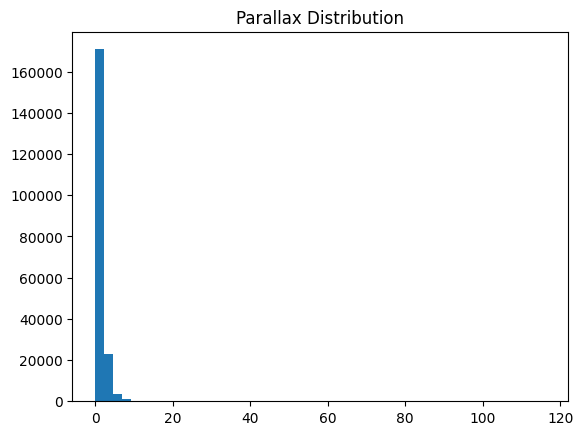

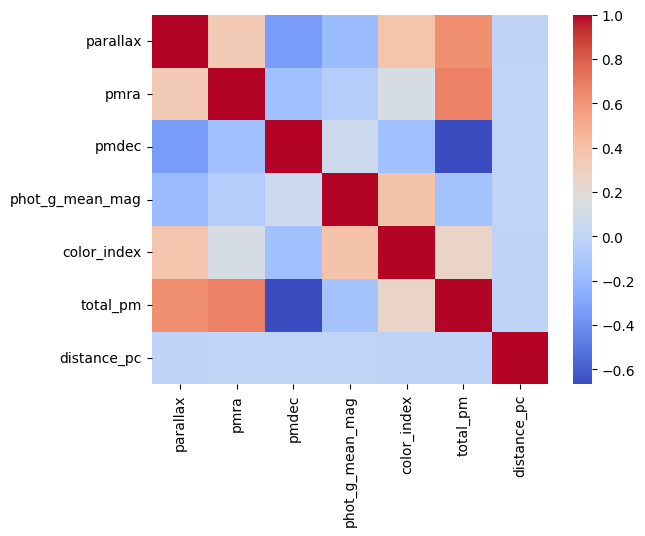

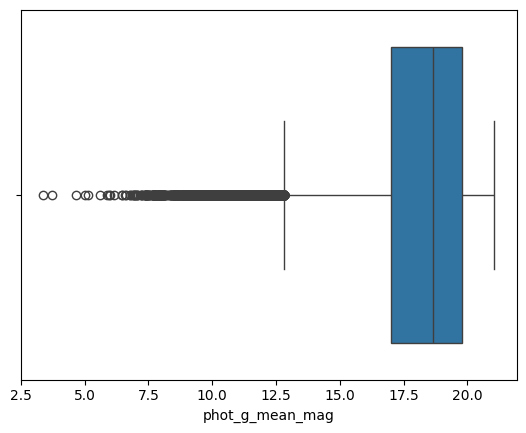

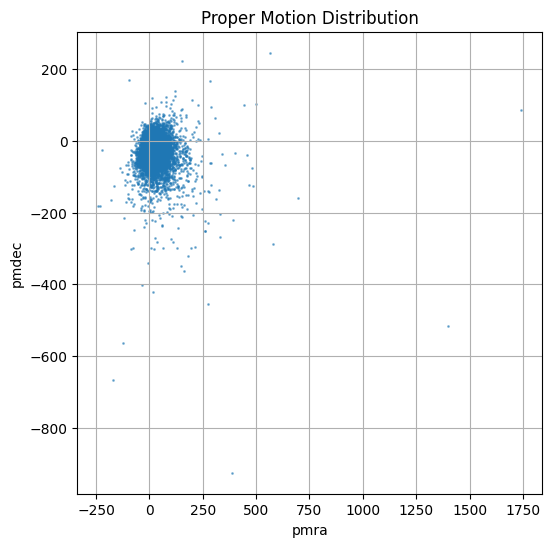

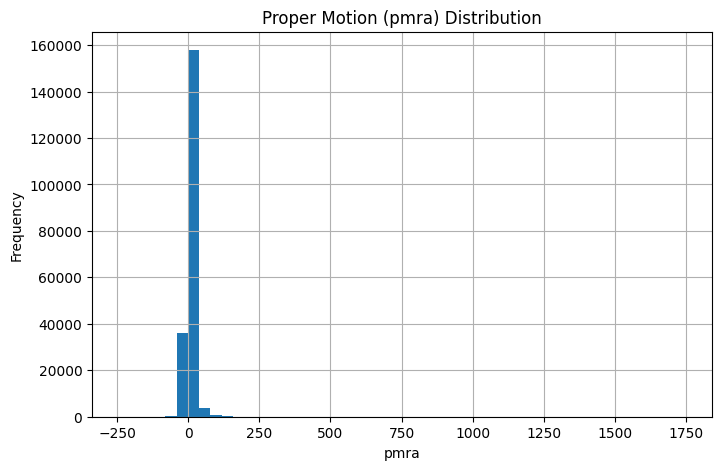

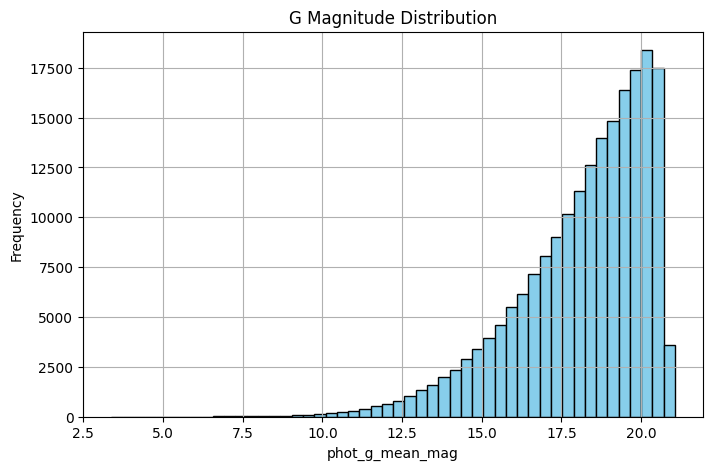

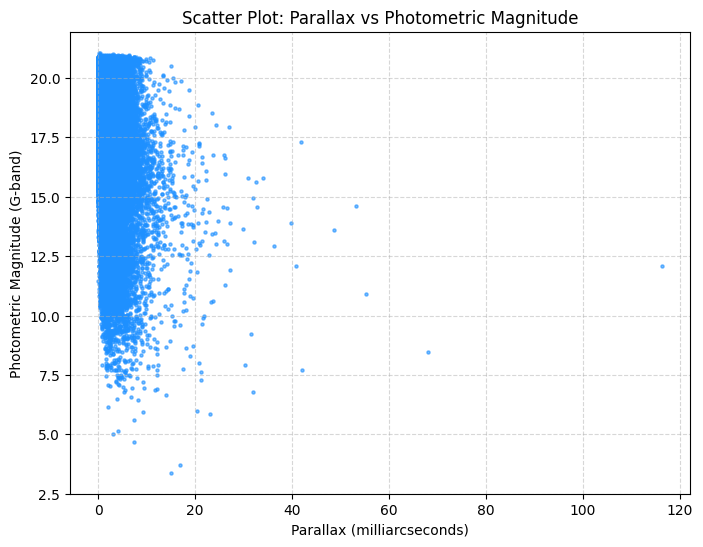

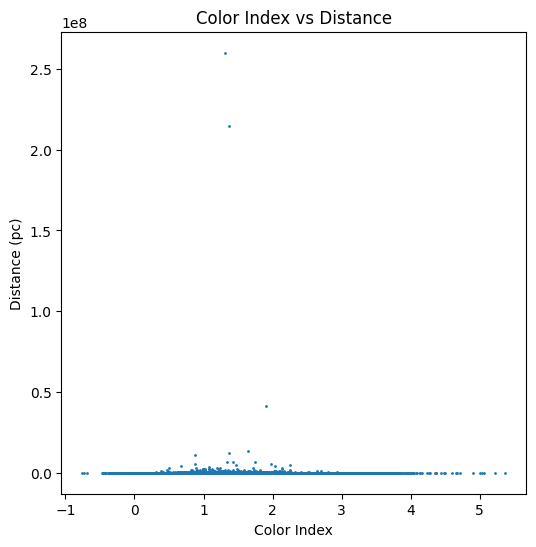

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.hist(data['parallax'], bins=50)
plt.title("Parallax Distribution")
plt.show()

# Correlation heatmap
sns.heatmap(data[['parallax','pmra','pmdec','phot_g_mean_mag',
                  'color_index','total_pm','distance_pc']].corr(),
            cmap='coolwarm', annot=False)
plt.show()

# Boxplot
sns.boxplot(x=data['phot_g_mean_mag'])
plt.show()
# Scatter: pmra vs pmdec
plt.figure(figsize=(6,6))
plt.scatter(data['pmra'], data['pmdec'], s=1,alpha=0.5)
plt.xlabel("pmra")
plt.ylabel("pmdec")
plt.title("Proper Motion Distribution")
plt.grid(True)
plt.show()

#Histogram :pmra
plt.figure(figsize=(8,5))
plt.hist(data['pmra'], bins=50)
plt.title("Proper Motion (pmra) Distribution")
plt.xlabel("pmra")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Histogram: phot_g_mean_mag
plt.figure(figsize=(8,5))
plt.hist(data['phot_g_mean_mag'], bins=50,color='skyblue', edgecolor='black')
plt.title("G Magnitude Distribution")
plt.xlabel("phot_g_mean_mag")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(data['parallax'], data['phot_g_mean_mag'], s=5, color='dodgerblue',
            alpha=0.6)
plt.title("Scatter Plot: Parallax vs Photometric Magnitude")
plt.xlabel("Parallax (milliarcseconds)")
plt.ylabel("Photometric Magnitude (G-band)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Optional: Scatter color_index vs distance_pc
plt.figure(figsize=(6,6))
plt.scatter(data['color_index'], data['distance_pc'], s=1)
plt.xlabel("Color Index")
plt.ylabel("Distance (pc)")
plt.title("Color Index vs Distance")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
# Add engineered features to PCA
features_full = data[['parallax','pmra','pmdec','phot_g_mean_mag',
                    'color_index','total_pm','distance_pc']]

# Scale all features
scaled_full = StandardScaler().fit_transform(features_full)

# Convert to DataFrame to show scaled values
scaled_data = pd.DataFrame(scaled_full, columns=features_full.columns)
print(scaled_data.head())  # Screenshot this for report

   parallax       pmra     pmdec  phot_g_mean_mag  color_index   total_pm  \
0  0.981017  -0.224124 -0.575794         0.224763     1.543415   0.085320   
1  0.717863   0.532626 -0.563979        -0.138985     0.961020   0.388823   
2 -0.250627  -0.030506  0.423258         1.048418     0.218481  -0.429049   
3  4.683990  14.293935  3.370095        -0.901285     1.245079  11.994977   
4 -0.564600  -0.171254  0.087187        -0.906196    -1.195499  -0.372443   

   distance_pc  
0    -0.007905  
1    -0.007828  
2    -0.007033  
3    -0.008220  
4    -0.005858  


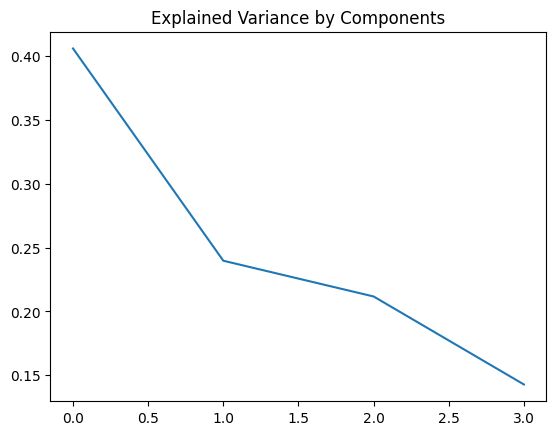

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
features = data[['parallax','pmra','pmdec','phot_g_mean_mag']]
scaled = StandardScaler().fit_transform(features)
pca = PCA()
pca_data = pca.fit_transform(scaled)
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by Components")
plt.show()

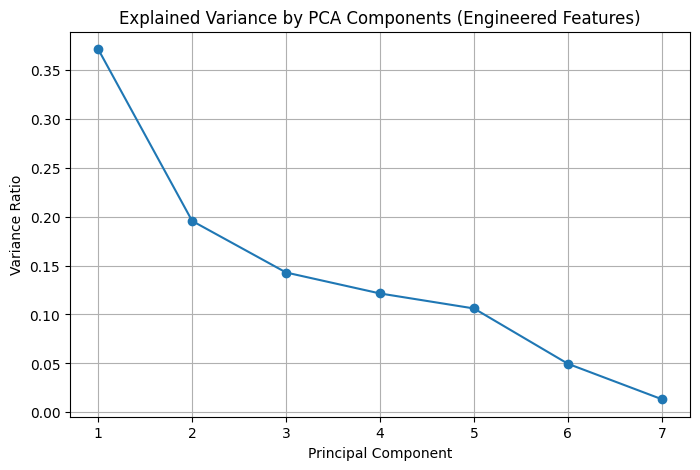

Total variance explained by first 2 components (engineered): 0.5664501299372434
Head of PCA-transformed engineered features:
          PC1       PC2
0   1.061417  1.162895
1   1.295589  0.410530
2  -0.585132  0.987727
3  14.207053 -2.076232
4  -0.844795 -1.402729


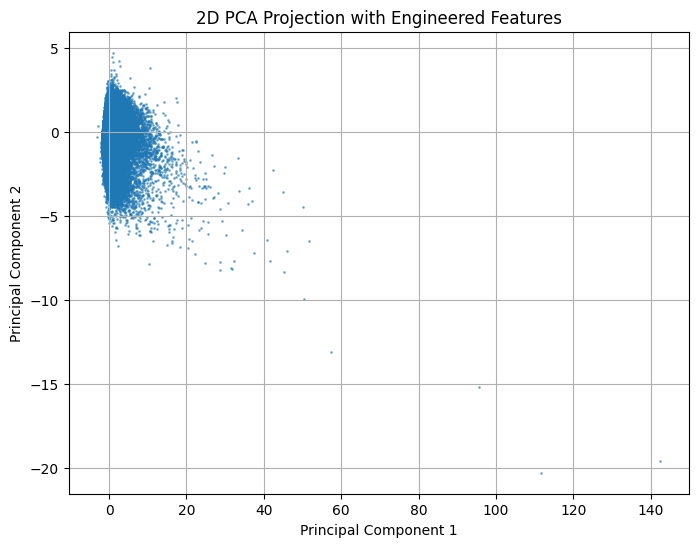

PCA-transformed engineered data saved as 'pca_engineered_data.csv'


In [ ]:
# -----------------------------
# PCA with engineered features
# -----------------------------

# Include engineered features
features_engineered = data[['parallax','pmra','pmdec','phot_g_mean_mag',
                          'color_index','total_pm','distance_pc']]

# Scale the features
scaled_engineered = StandardScaler().fit_transform(features_engineered)

# Perform PCA without reducing dimensions
pca_engineered = PCA()
pca_data_engineered = pca_engineered.fit_transform(scaled_engineered)

# Plot explained variance ratio for engineered features
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_engineered.explained_variance_ratio_)+1),
         pca_engineered.explained_variance_ratio_, marker='o')
plt.title("Explained Variance by PCA Components (Engineered Features)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()

# Total variance explained by first 2 components
print("Total variance explained by first 2 components (engineered):",
      sum(pca_engineered.explained_variance_ratio_[:2]))

# Reduce to 2 components for visualization
pca_engineered_2 = PCA(n_components=2)
pca_components_engineered = pca_engineered_2.fit_transform(scaled_engineered)

# Create a new DataFrame for PCA-transformed engineered features
pca_data_engineered = pd.DataFrame(data=pca_components_engineered,
                                 columns=['PC1', 'PC2'])
print("Head of PCA-transformed engineered features:\n", pca_data_engineered.head())

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_data_engineered['PC1'], pca_data_engineered['PC2'], s=1, alpha=0.5)
plt.title("2D PCA Projection with Engineered Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Save for next phases
pca_data_engineered.to_csv("pca_engineered_data.csv", index=False)
print("PCA-transformed engineered data saved as 'pca_engineered_data.csv'")